In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
pd.options.mode.use_inf_as_na = True
import tkinter
from tkinter import filedialog

In [3]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()

In [4]:
# df_files = {}
# i = 0

# for root, dirs, files in os.walk(filepath):
#     if ".csv" in str(files) and "Trial" in str(files):
#         for f in listdir(path=root):
#             if ".csv" in str(f):
#                     a = pd.read_csv(root + '\\' + f)
#                     y = a.xs('Y (cm)', axis=1)
#                     x = a.xs('X (cm)', axis=1)
#                     speed = a.xs('SPEED#wcentroid (cm/s)', axis=1)
#                     vy = a.xs('VY (cm/s)', axis=1)
#                     frame = a.frame
#                     df_files[str(i)] = pd.DataFrame({"Y" : y, "X" : x, "Speed" : speed, "VY" : vy, "Frame" : frame, "Trial" : str(f), "Condition" : str(root.rsplit('\\')[-2])})
#                     i = i+1

# complete_df = pd.concat(df_files)

In [5]:
df_files = {}
i = 0

for root, dirs, files in os.walk(filepath):
    if ".csv" in str(files) and "Trial" in str(files):
        for f in listdir(path=root):
            if ".csv" in str(f):
                    a = pd.read_csv(root + '\\' + f)
                    y = a.xs('Y (cm)', axis=1)
                    x = a.xs('X (cm)', axis=1)
                    speed = a.xs('SPEED#wcentroid (cm/s)', axis=1)
                    vy = a.xs('VY (cm/s)', axis=1)
                    frame = a.frame
                    df_files[str(i)] = pd.DataFrame({"Y" : y, "X" : x, "Speed" : speed, "VY" : vy, "Frame" : frame, "Trial" : str(root.rsplit('\\')[-1]), "Condition" : str(root.rsplit('\\')[-2])})
                    i = i+1

complete_df = pd.concat(df_files)

In [6]:
#Cleaning the data: ridding it of infs
clean_complete_df = complete_df.dropna()

clean_complete_df.head()


Y       X  Speed     VY  Frame    Trial        Condition
0 0  16.427  13.335  0.000  0.000    0.0  Trial 1  Orco - 10-3 cVA
  1  16.667  13.137  0.441  2.396    1.0  Trial 1  Orco - 10-3 cVA
  2  16.450  13.318  0.239 -2.166    2.0  Trial 1  Orco - 10-3 cVA
  3  16.440  13.320  0.086 -0.101    3.0  Trial 1  Orco - 10-3 cVA
  4  16.447  13.325  0.350  0.074    4.0  Trial 1  Orco - 10-3 cVA

In [26]:
conditions = clean_complete_df['Condition'].unique().tolist()

trials_dict = {}

for cond in conditions:
    key = f'{cond}'
    sub_df = clean_complete_df[clean_complete_df['Condition'] == cond] 
    value = sub_df['Trial'].unique().tolist()
    trials_dict[key] = value



In [8]:
#Inserting a distance column
clean_complete_df.insert(4, 'Distance', 0)

In [9]:
for cond in conditions:
    for trial in trials_dict[f'{cond}']:
        sub_df = clean_complete_df[(clean_complete_df['Condition'] == cond) & (clean_complete_df['Trial'] == trial)]
        #Calculating centroid position

        x_centroid_list = []
        y_centroid_list = []

        frame_list = sub_df['Frame'].values.tolist()
        for f in range(0, int(max(frame_list))):
            cropped_pos = sub_df.loc[sub_df['Frame'] == f]
            av_x = cropped_pos['X'].mean()
            x_centroid_list.append(av_x)
            av_y = cropped_pos['Y'].mean()
            y_centroid_list.append(av_y)

        coordlist = list(zip(x_centroid_list, y_centroid_list))
        t = np.arange(np.size(x_centroid_list))

        x_1 = x_centroid_list[0]
        y_1 = y_centroid_list[0]

        for f in sub_df.index:
            x_2 = sub_df.X[f]
            y_2 = sub_df.Y[f]
            dist = math.sqrt((x_2-x_1)**2 + (y_2-y_1)**2)
            clean_complete_df.Distance[f] = dist



C:\Users\hpnhp\AppData\Local\Temp\ipykernel_15008\2614076390.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_complete_df.Distance[f] = dist


In [2]:
#Pulling Distance Data from External File

clean_complete_df = pd.read_csv(r'D:/Experiment Work/larva-locater/Experimental/distances.csv')

In [7]:
distance_grouped = clean_complete_df.groupby(['Condition', 'Trial']).Distance.mean()

distance_grouped = distance_grouped.reset_index()

In [8]:
distance_grouped = distance_grouped.pivot(index='Trial', columns='Condition', values = 'Distance')

In [9]:
distance_grouped.head()

Condition,Orco - 10-3 cVA,Orco - Ethanol,Orco - Water,WT - 10-3 cVA,WT - Ethanol,WT - Water,ppk23 10-3 cVA in Ethanol
Trial,,,,,,,
Trial 1,4.311144,1.988265,3.900844,4.171842,4.305465,6.151770,4.182442
Trial 2,4.299338,2.646228,2.719150,2.285367,4.551393,3.140560,5.419456
Trial 3,3.426997,2.389982,3.664560,4.522853,4.625026,3.331857,4.968993
Trial 4,5.243393,4.234965,4.412643,4.067601,5.091123,2.588960,4.774397
Trial 5,4.335701,4.078095,3.404714,3.908813,5.154159,5.778377,5.071060


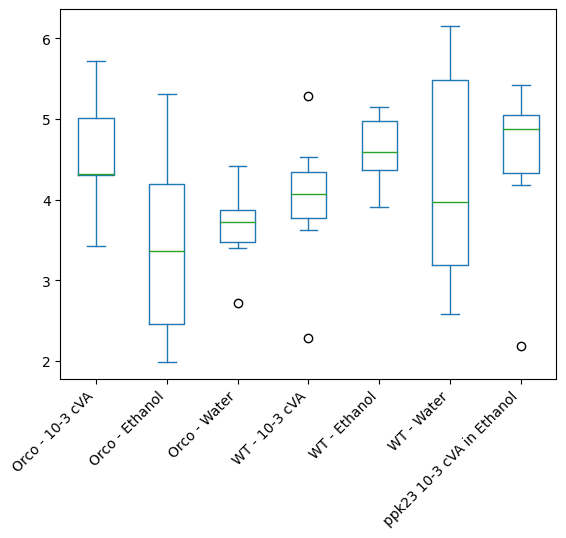

In [10]:
#for index in distance_grouped.index:
    #sbs.boxenplot(data = distance_grouped, x = distance_grouped[index], y = 'Condition')

ax = distance_grouped.plot(kind='box')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels by 45 degrees

plt.show()

#sbs.boxenplot(x='Condition', y='Distance', data=distance_grouped, color='blue', width=0.4)
#plt.legend()
#plt.show()

<AxesSubplot: xlabel='Frame', ylabel='Distance'>

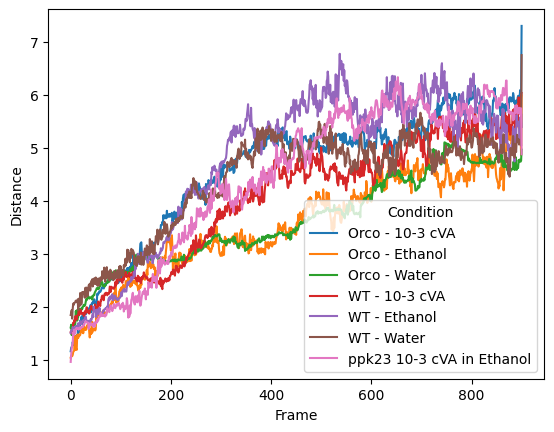

In [11]:
frame_dist_df = clean_complete_df.groupby(['Condition', 'Frame']).Distance.mean()

sbs.lineplot(data = frame_dist_df, x = 'Frame' ,y = frame_dist_df, hue = 'Condition')

<AxesSubplot: xlabel='Frame', ylabel='Distance'>

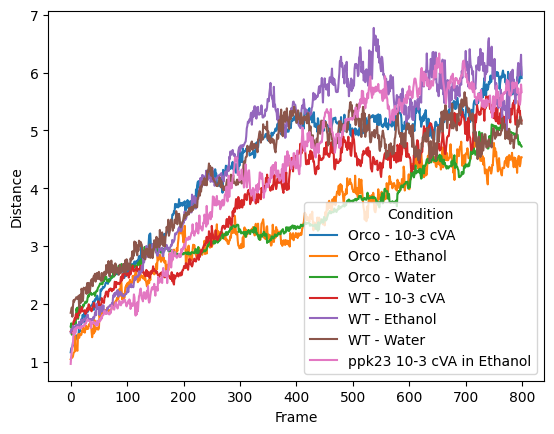

In [12]:
#To analyze cropped parts of the dataset

cropped_ccd = clean_complete_df[clean_complete_df['Frame']<800]

frame_dist_df = cropped_ccd.groupby(['Condition', 'Frame']).Distance.mean()

sbs.lineplot(data = frame_dist_df, x = 'Frame' ,y = frame_dist_df, hue = 'Condition')

In [35]:
#frame_dist_df_WT = frame_dist_df[frame_dist_df['Condition'] == 'WT -Ethanol']

#frame_dist_df = frame_dist_df.reset_index()

In [13]:
frame_dist_df_WT =  cropped_ccd[(cropped_ccd['Condition'] == 'WT - Ethanol') | (cropped_ccd['Condition'] == 'WT - Water') | (cropped_ccd['Condition'] == 'WT - 10-3 cVA')]

<AxesSubplot: xlabel='Frame', ylabel='Distance'>

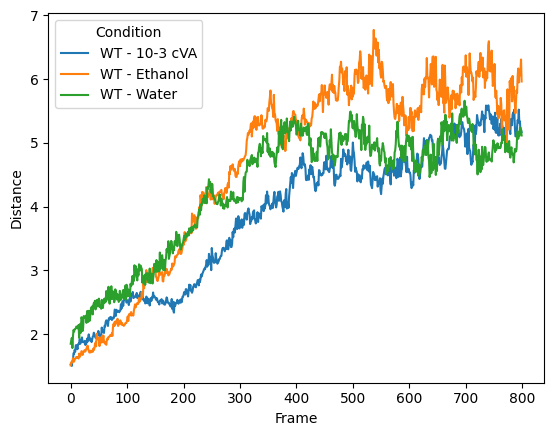

In [14]:
frame_dist_df_WT = frame_dist_df_WT.groupby(['Condition', 'Frame']).Distance.mean()

sbs.lineplot(data = frame_dist_df_WT, x = 'Frame' ,y = frame_dist_df, hue = 'Condition')

In [15]:
frame_dist_df_Orco = cropped_ccd[(cropped_ccd['Condition'] == 'Orco - Ethanol') | (cropped_ccd['Condition'] == 'Orco - Water') | (cropped_ccd['Condition'] == 'Orco - 10-3 cVA')]



<AxesSubplot: xlabel='Frame', ylabel='Distance'>

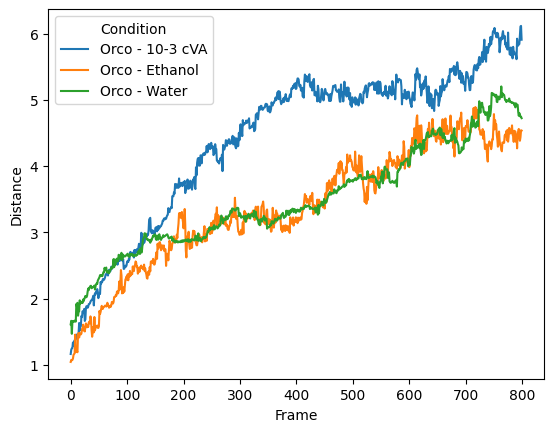

In [16]:
frame_dist_df_Orco = frame_dist_df_Orco.groupby(['Condition', 'Frame']).Distance.mean()

sbs.lineplot(data = frame_dist_df_Orco, x = 'Frame' ,y = frame_dist_df, hue = 'Condition')

In [32]:
#Retention Index - a per-frame breakdown of the number of larvae inside vs outside a distance of 3cm from the intially defined centroid (distance metric)

retention_df = clean_complete_df.copy()

In [33]:
def compare_to_constant(df, column_name, constant):
    # Create a new column based on the comparison
    df['Side'] = (df[column_name] < constant).astype(int)
    
    return df

In [ ]:
def retention_index(df, condition, trial):
    # Sum up the side values of the trial on a per-frame basis
    frame_list = df['Frame'].values.tolist()
    for f in range(0, int(max(frame_list))):
            cropped_pos = sub_df.loc[sub_df['Frame'] == f]


In [38]:
retention_df = compare_to_constant(retention_df, 'Distance', 3)

for cond in conditions:
    for trial in trials_dict[f'{cond}']:
        sub_df = clean_complete_df[(clean_complete_df['Condition'] == cond) & (clean_complete_df['Trial'] == trial)]

        frame_list = sub_df['Frame'].values.tolist()
        for f in range(0, int(max(frame_list))):
            cropped_pos = sub_df.loc[sub_df['Frame'] == f]
            

       

#         #for f in sub_df.index:
#         #    x_2 = sub_df.X[f]
#         #    y_2 = sub_df.Y[f]
#         #    dist = math.sqrt((x_2-x_1)**2 + (y_2-y_1)**2)
#         #    clean_complete_df.Distance[f] = dist

